MLP:
확장 속성 + method
→ type_effect 예측
→ 효과 수치 예측

LLM:
재료 이름 + 재료 설명 + MLP 예측 결과
→ item_name 생성
→ item_note 생성

In [3]:
!pip install -q openai pandas openpyxl scikit-learn matplotlib torch

In [4]:
import random
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report, confusion_matrix, ConfusionMatrixDisplay

from openai import OpenAI
from google.colab import userdata, files

In [14]:
# =========================
# 1. 기본 설정
# =========================

CRAFT_DATA_PATH = "generated_crafting_dataset_rule_llm_4000.xlsx"
MATERIAL_DATA_PATH = "material_master_dataset_120.xlsx"

RANDOM_STATE = 42
TEST_SIZE = 0.2

BATCH_SIZE = 32
EPOCHS = 300

LEARNING_RATE = 1e-3      # 0.001
REG_LOSS_WEIGHT = 0.5

HIDDEN_DIMS = [256, 128, 64]

OPENAI_MODEL_NAME = "gpt-4.1-mini"
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [15]:
# =========================
# 2. 파일 업로드
# =========================

uploaded = files.upload()

# 필요 파일:
# 1. generated_crafting_dataset_rule_llm_2000.xlsx
# 2. material_master_dataset_120.xlsx

Saving generated_crafting_dataset_rule_llm_4000.xlsx to generated_crafting_dataset_rule_llm_4000 (1).xlsx
Saving material_master_dataset_120.xlsx to material_master_dataset_120 (1).xlsx


In [16]:
# =========================
# 3. 데이터 로드
# =========================

df = pd.read_excel(CRAFT_DATA_PATH)
material_df = pd.read_excel(MATERIAL_DATA_PATH, sheet_name="materials")

print("Crafting dataset:", df.shape)
print("Material dataset:", material_df.shape)

display(df.head())
display(material_df.head())

Crafting dataset: (4000, 41)
Material dataset: (120, 29)


,ingredient1,ingredient2,method,item_name,item_note,type_effect,hp,poison,duration,attack,...,electric,explosive,fragile,dense,dark,holy,sharp,defensive,power_score,value_score
0,영혼 천 조각,별철 파편,boil,별빛 수호 망토,"영혼의 기운과 별철의 힘이 깃든 망토로, 3초간 강력한 방어력을 부여한다.",방어형,0,0,3,0,...,0,0,1,1,1,0,0,1,12,12
1,고요한 민트,천둥석,forge,민트 천둥의 치유석,차가운 민트 향과 천둥석의 힘이 어우러져 6초간 30의 체력을 회복시킨다.,회복형,30,0,6,0,...,1,0,0,1,0,0,0,0,9,10
2,휘발성 가루,푸른 이슬꽃,forge,휘발성 이슬포션,충격에 반응하는 가루와 맑은 이슬꽃으로 만든 짧은 시간 회복 물약.,회복형,34,0,5,0,...,1,1,1,0,0,0,0,0,5,4
3,영혼 천 조각,그늘진 수액,distill,어둠의 독액 천,"영혼 천 조각과 그늘진 수액을 증류하여 만든 독성 천. 적에게 독과 냉기, 충격을 ...",디버프형,0,14,16,0,...,0,0,1,0,2,0,0,0,7,6
4,독버섯,영혼 천 조각,infuse,영혼독 버섯 주입체,"영혼 천 조각에 독버섯의 맹독을 주입하여 적에게 중독과 빙결, 감전을 일으키는 저주...",디버프형,0,14,18,0,...,0,0,2,0,2,0,0,0,5,3


,item_id,name_kr,category,rarity,toxic,healing,viscous,stable,organic,plant,...,explosive,fragile,dense,dark,holy,sharp,defensive,power_score,value_score,note
0,I001,독버섯,plant,common,1,0,0,0,0,1,...,0,1,0,1,0,0,0,2,1,강한 독성을 가진 불안정한 버섯
1,I002,빨간 약초,plant,common,0,1,0,1,0,1,...,0,1,0,0,0,0,0,2,1,기본 회복 재료
2,I003,슬라임 점액,organic,common,0,0,1,0,1,0,...,0,1,0,0,0,0,0,1,1,점성이 강한 저급 생체 재료
3,I004,숯가루,mineral,common,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,1,탄화 성질
4,I005,정제수,liquid,common,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,1,중화 및 희석


In [17]:
# =========================
# 4. 컬럼 설정
# =========================

MATERIAL_ATTR_COLS = [
    "toxic", "healing", "viscous", "stable", "organic",
    "plant", "unstable", "burnt", "neutral", "pure",
    "metallic", "magical", "cold", "hot", "electric",
    "explosive", "fragile", "dense", "dark", "holy",
    "sharp", "defensive"
]

METHOD_COLS = [
    "boil", "grind", "mix", "bake",
    "infuse", "compress", "distill", "forge"
]

EFFECT_TYPE_COL = "type_effect"

REG_COLS = [
    "hp", "poison", "duration",
    "attack", "defense", "speed", "resistance",
    "burn", "freeze", "shock", "explosion_damage"
]

INPUT_COLS = MATERIAL_ATTR_COLS + METHOD_COLS

In [18]:
# =========================
# 5. 전처리
# =========================

for method in METHOD_COLS:
    df[method] = (df["method"] == method).astype(int)

effect_encoder = LabelEncoder()
df["effect_type_encoded"] = effect_encoder.fit_transform(df[EFFECT_TYPE_COL])

X = df[INPUT_COLS].values.astype(np.float32)
y_effect = df["effect_type_encoded"].values.astype(np.int64)
y_reg = df[REG_COLS].values.astype(np.float32)

X_train, X_test, y_effect_train, y_effect_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_effect,
    y_reg,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_effect
)

print("Train:", len(X_train))
print("Test:", len(X_test))
print("Effect classes:", list(effect_encoder.classes_))

Train: 3200
Test: 800
Effect classes: ['공격형', '독성형', '디버프형', '방어형', '버프형', '속성형', '잡동사니', '회복형']


In [19]:
# =========================
# 6. TensorDataset 생성
# =========================

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_effect_train_t = torch.tensor(y_effect_train, dtype=torch.long)
y_effect_test_t = torch.tensor(y_effect_test, dtype=torch.long)

y_reg_train_t = torch.tensor(y_reg_train, dtype=torch.float32)
y_reg_test_t = torch.tensor(y_reg_test, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_effect_train_t, y_reg_train_t)
test_ds = TensorDataset(X_test_t, y_effect_test_t, y_reg_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
# =========================
# 7. MLP 모델 정의
# =========================

class CraftingMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_effect_classes, reg_dim):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
            prev_dim = h

        self.shared = nn.Sequential(*layers)

        self.effect_head = nn.Linear(prev_dim, num_effect_classes)
        self.reg_head = nn.Linear(prev_dim, reg_dim)

    def forward(self, x):
        feat = self.shared(x)
        effect_logits = self.effect_head(feat)
        reg_out = self.reg_head(feat)
        return effect_logits, reg_out


model = CraftingMLP(
    input_dim=len(INPUT_COLS),
    hidden_dims=HIDDEN_DIMS,
    num_effect_classes=len(effect_encoder.classes_),
    reg_dim=len(REG_COLS)
).to(device)

criterion_cls = nn.CrossEntropyLoss()
criterion_reg = nn.L1Loss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

CraftingMLP(
  (shared): Sequential(
    (0): Linear(in_features=30, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
  )
  (effect_head): Linear(in_features=64, out_features=8, bias=True)
  (reg_head): Linear(in_features=64, out_features=11, bias=True)
)


In [21]:
# =========================
# 8. MLP 학습
# =========================

train_loss_history = []
train_cls_loss_history = []
train_reg_loss_history = []

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0
    running_cls_loss = 0.0
    running_reg_loss = 0.0

    for xb, yb_effect, yb_reg in train_loader:
        xb = xb.to(device)
        yb_effect = yb_effect.to(device)
        yb_reg = yb_reg.to(device)

        optimizer.zero_grad()

        pred_effect, pred_reg = model(xb)

        loss_cls = criterion_cls(pred_effect, yb_effect)
        loss_reg = criterion_reg(pred_reg, yb_reg)

        loss = loss_cls + REG_LOSS_WEIGHT * loss_reg

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_cls_loss += loss_cls.item()
        running_reg_loss += loss_reg.item()

    avg_loss = running_loss / len(train_loader)
    avg_cls_loss = running_cls_loss / len(train_loader)
    avg_reg_loss = running_reg_loss / len(train_loader)

    train_loss_history.append(avg_loss)
    train_cls_loss_history.append(avg_cls_loss)
    train_reg_loss_history.append(avg_reg_loss)

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Loss: {avg_loss:.4f} | "
            f"Cls: {avg_cls_loss:.4f} | "
            f"Reg: {avg_reg_loss:.4f}"
        )

Epoch [20/300] Loss: 0.6786 | Cls: 0.0569 | Reg: 1.2434
Epoch [40/300] Loss: 0.4784 | Cls: 0.0176 | Reg: 0.9216
Epoch [60/300] Loss: 0.3903 | Cls: 0.0059 | Reg: 0.7688
Epoch [80/300] Loss: 0.3582 | Cls: 0.0154 | Reg: 0.6854
Epoch [100/300] Loss: 0.3164 | Cls: 0.0025 | Reg: 0.6277
Epoch [120/300] Loss: 0.3080 | Cls: 0.0025 | Reg: 0.6111
Epoch [140/300] Loss: 0.3004 | Cls: 0.0083 | Reg: 0.5841
Epoch [160/300] Loss: 0.2738 | Cls: 0.0016 | Reg: 0.5443
Epoch [180/300] Loss: 0.2719 | Cls: 0.0055 | Reg: 0.5328
Epoch [200/300] Loss: 0.2599 | Cls: 0.0026 | Reg: 0.5145
Epoch [220/300] Loss: 0.2841 | Cls: 0.0127 | Reg: 0.5427
Epoch [240/300] Loss: 0.2710 | Cls: 0.0131 | Reg: 0.5156
Epoch [260/300] Loss: 0.2558 | Cls: 0.0011 | Reg: 0.5094
Epoch [280/300] Loss: 0.2508 | Cls: 0.0045 | Reg: 0.4925
Epoch [300/300] Loss: 0.2471 | Cls: 0.0038 | Reg: 0.4866


In [22]:
# =========================
# 9. MLP 평가
# =========================

model.eval()

all_effect_preds = []
all_effect_true = []

all_reg_preds = []
all_reg_true = []

with torch.no_grad():
    for xb, yb_effect, yb_reg in test_loader:
        xb = xb.to(device)

        pred_effect, pred_reg = model(xb)

        effect_pred_labels = pred_effect.argmax(dim=1).cpu().numpy()
        reg_pred_vals = pred_reg.cpu().numpy()

        all_effect_preds.extend(effect_pred_labels.tolist())
        all_effect_true.extend(yb_effect.numpy().tolist())

        all_reg_preds.extend(reg_pred_vals.tolist())
        all_reg_true.extend(yb_reg.numpy().tolist())

all_reg_preds = np.array(all_reg_preds)
all_reg_true = np.array(all_reg_true)

effect_acc = accuracy_score(all_effect_true, all_effect_preds)

mae_by_col = {
    col: mean_absolute_error(all_reg_true[:, i], all_reg_preds[:, i])
    for i, col in enumerate(REG_COLS)
}

overall_mae = np.mean(list(mae_by_col.values()))

print("Effect Type Accuracy:", effect_acc)

print("\n=== Regression MAE ===")
for col, mae in mae_by_col.items():
    print(f"{col}: {mae:.4f}")

print("\nOverall MAE:", overall_mae)

print("\n=== Classification Report ===")
print(classification_report(
    all_effect_true,
    all_effect_preds,
    target_names=effect_encoder.classes_
))

Effect Type Accuracy: 0.96625

=== Regression MAE ===
hp: 0.4635
poison: 0.4608
duration: 0.7117
attack: 0.6247
defense: 0.4770
speed: 0.5173
resistance: 0.3906
burn: 0.2405
freeze: 0.1339
shock: 0.2236
explosion_damage: 0.3735

Overall MAE: 0.4197650414000863

=== Classification Report ===
              precision    recall  f1-score   support

         공격형       0.97      0.95      0.96        97
         독성형       0.97      0.96      0.97       134
        디버프형       0.96      0.97      0.97       109
         방어형       0.99      0.98      0.98       140
         버프형       0.95      0.95      0.95       134
         속성형       0.88      0.97      0.93        38
        잡동사니       0.87      0.93      0.90        14
         회복형       1.00      0.99      0.99       134

    accuracy                           0.97       800
   macro avg       0.95      0.96      0.95       800
weighted avg       0.97      0.97      0.97       800



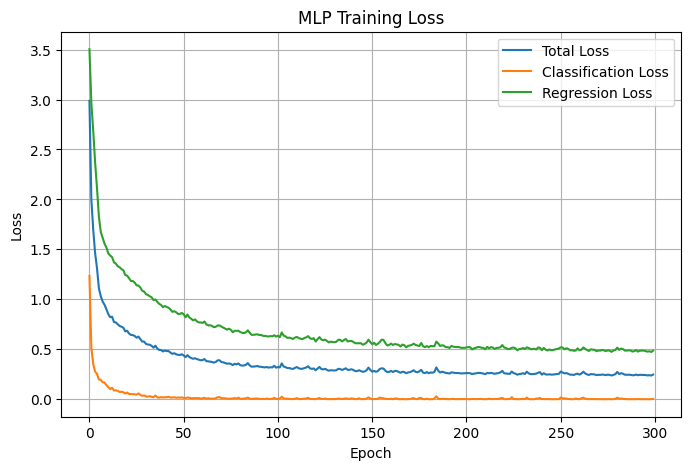

In [23]:
# =========================
# 10. 학습 그래프
# =========================

plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="Total Loss")
plt.plot(train_cls_loss_history, label="Classification Loss")
plt.plot(train_reg_loss_history, label="Regression Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.legend()
plt.grid(True)
plt.show()

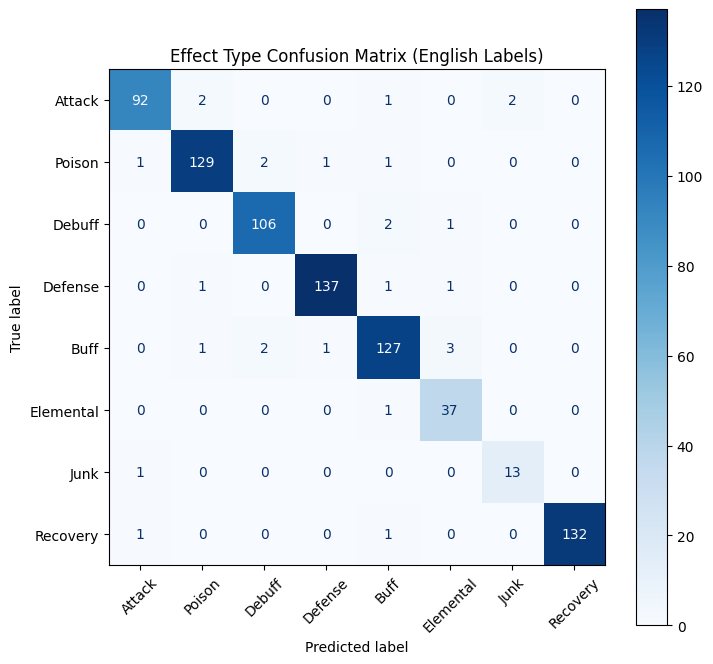

In [24]:
# =========================
# 11. Confusion Matrix
# =========================

# Define English labels for effect types
english_effect_labels = [
    "Attack", "Poison", "Debuff", "Defense",
    "Buff", "Elemental", "Junk", "Recovery"
]

cm = confusion_matrix(
    all_effect_true,
    all_effect_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=english_effect_labels # Use English labels here
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Effect Type Confusion Matrix (English Labels)") # Update title for clarity
plt.xticks(rotation=45)
plt.show()

In [25]:
print("=== Classification Accuracy ===")
print(f"type_effect accuracy: {effect_acc:.3f}")

print("\n=== Effect Value MAE ===")
for col, mae in mae_by_col.items():
    print(f"{col}: {mae:.3f}")

print(f"\nOverall MAE: {overall_mae:.3f}")

=== Classification Accuracy ===
type_effect accuracy: 0.966

=== Effect Value MAE ===
hp: 0.464
poison: 0.461
duration: 0.712
attack: 0.625
defense: 0.477
speed: 0.517
resistance: 0.391
burn: 0.240
freeze: 0.134
shock: 0.224
explosion_damage: 0.374

Overall MAE: 0.420


In [26]:
# =========================
# 12. 재료 정보 조회용 딕셔너리
# =========================

material_lookup = material_df.set_index("name_kr").to_dict("index")

def safe_int(value, default=0):
    try:
        if pd.isna(value):
            return default
        return int(value)
    except:
        return default


def get_material_context_by_name(name):
    if name not in material_lookup:
        return f"""
재료명: {name}
정보: 재료 마스터 데이터셋에서 찾을 수 없음
""".strip()

    m = material_lookup[name]

    attr_text = ", ".join([
        f"{col}={safe_int(m.get(col, 0))}"
        for col in MATERIAL_ATTR_COLS
        if col in m
    ])

    return f"""
재료명: {m.get("name_kr", name)}
영문명: {m.get("name_en", "")}
카테고리: {m.get("category", "")}
희귀도: {m.get("rarity", "")}
속성: {attr_text}
power_score: {safe_int(m.get("power_score", 0))}
value_score: {safe_int(m.get("value_score", 0))}
note: {m.get("note", "")}
""".strip()

In [27]:
# =========================
# 13. 단일 조합 MLP 예측 함수
# =========================

def make_input_from_ingredients(ingredient1, ingredient2, method):
    if ingredient1 not in material_lookup:
        raise ValueError(f"재료를 찾을 수 없음: {ingredient1}")

    if ingredient2 not in material_lookup:
        raise ValueError(f"재료를 찾을 수 없음: {ingredient2}")

    mat1 = material_lookup[ingredient1]
    mat2 = material_lookup[ingredient2]

    row = {}

    for col in MATERIAL_ATTR_COLS:
        row[col] = safe_int(mat1.get(col, 0)) + safe_int(mat2.get(col, 0))

    for m in METHOD_COLS:
        row[m] = 1 if method == m else 0

    x = np.array([[row[col] for col in INPUT_COLS]], dtype=np.float32)

    return x


def predict_with_mlp(ingredient1, ingredient2, method):
    x = make_input_from_ingredients(ingredient1, ingredient2, method)
    x_t = torch.tensor(x, dtype=torch.float32).to(device)

    model.eval()

    with torch.no_grad():
        effect_logits, reg_out = model(x_t)

        effect_idx = effect_logits.argmax(dim=1).cpu().numpy()[0]
        pred_type_effect = effect_encoder.inverse_transform([effect_idx])[0]

        pred_values = reg_out.cpu().numpy()[0]

    result = {
        "ingredient1": ingredient1,
        "ingredient2": ingredient2,
        "method": method,
        "pred_type_effect": pred_type_effect
    }

    for i, col in enumerate(REG_COLS):
        result[f"pred_{col}"] = max(0, round(float(pred_values[i]), 2))

    return result

In [28]:
# =========================
# 14. LLM 프롬프트 생성
# =========================

def make_hybrid_llm_prompt(mlp_result):
    mat1_context = get_material_context_by_name(mlp_result["ingredient1"])
    mat2_context = get_material_context_by_name(mlp_result["ingredient2"])

    effect_values_text = "\n".join([
        f"- {col}: {mlp_result.get(f'pred_{col}', 0)}"
        for col in REG_COLS
    ])

    return f"""
너는 게임의 동적 크래프팅 시스템에서 아이템 이름과 도감 설명을 생성하는 AI다.

아래 정보는 MLP 모델이 예측한 제작 결과다.
LLM은 타입과 수치를 다시 예측하지 말고,
MLP 결과를 참고하여 아이템 이름과 설명만 생성해야 한다.

[재료 1 정보]
{mat1_context}

[재료 2 정보]
{mat2_context}

[제작 방식]
{mlp_result["method"]}

[MLP 예측 결과]
효과 타입(type_effect): {mlp_result["pred_type_effect"]}

[MLP 예측 효과 수치]
{effect_values_text}

생성 조건:
- item_name은 한국어 아이템 이름으로 생성한다.
- item_note는 게임 도감에 들어갈 수 있는 짧은 설명으로 작성한다.
- 재료의 이름, note, MLP가 예측한 효과 타입과 수치가 서로 어울려야 한다.
- type_effect와 효과 수치는 출력하지 않는다.
- JSON만 출력한다.

출력 형식:
{{
  "item_name": "아이템 이름",
  "item_note": "아이템 설명"
}}
""".strip()

In [29]:
# =========================
# 15. OpenAI로 이름 / 설명 생성
# =========================

def generate_name_note_with_llm(mlp_result, max_retry=3):
    prompt = make_hybrid_llm_prompt(mlp_result)
    last_error = ""

    for _ in range(max_retry):
        try:
            response = client.responses.create(
                model=OPENAI_MODEL_NAME,
                input=[
                    {
                        "role": "system",
                        "content": "너는 게임 크래프팅 결과에 어울리는 한국어 아이템 이름과 도감 설명을 생성하는 AI다."
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                text={
                    "format": {
                        "type": "json_schema",
                        "name": "hybrid_item_text_result",
                        "strict": True,
                        "schema": {
                            "type": "object",
                            "properties": {
                                "item_name": {
                                    "type": "string"
                                },
                                "item_note": {
                                    "type": "string"
                                }
                            },
                            "required": ["item_name", "item_note"],
                            "additionalProperties": False
                        }
                    }
                },
                temperature=0.6
            )

            parsed = json.loads(response.output_text)

            return parsed["item_name"], parsed["item_note"]

        except Exception as e:
            last_error = str(e)
            time.sleep(1.5)

    return "이름 생성 실패", f"설명 생성 실패: {last_error}"

In [30]:
# =========================
# 16. 하이브리드 모델 최종 함수
# =========================

def hybrid_crafting_predict(ingredient1, ingredient2, method):
    mlp_result = predict_with_mlp(ingredient1, ingredient2, method)

    item_name, item_note = generate_name_note_with_llm(mlp_result)

    final_result = {
        "ingredient1": ingredient1,
        "ingredient2": ingredient2,
        "method": method,

        "item_name": item_name,
        "item_note": item_note,

        "type_effect": mlp_result["pred_type_effect"]
    }

    for col in REG_COLS:
        final_result[col] = mlp_result[f"pred_{col}"]

    return final_result

In [31]:
# =========================
# 17. 하이브리드 모델 테스트
# =========================

test_ingredient1 = df.iloc[0]["ingredient1"]
test_ingredient2 = df.iloc[0]["ingredient2"]
test_method = df.iloc[0]["method"]

result = hybrid_crafting_predict(
    test_ingredient1,
    test_ingredient2,
    test_method
)

result

{'ingredient1': '영혼 천 조각',
 'ingredient2': '별철 파편',
 'method': 'boil',
 'item_name': '별빛 영혼의 방어구',
 'item_note': '영혼 천 조각과 별철 파편을 끓여 만든 마법 방어구로, 강력한 방어력과 저항력을 부여한다.',
 'type_effect': '방어형',
 'hp': 0,
 'poison': 0.02,
 'duration': 3.79,
 'attack': 0.01,
 'defense': 30.82,
 'speed': 7.42,
 'resistance': 7.94,
 'burn': 0,
 'freeze': 0,
 'shock': 0.01,
 'explosion_damage': 0}

In [32]:
# =========================
# 18. 여러 개 샘플 테스트
# =========================

sample_inputs = df.sample(5, random_state=RANDOM_STATE)[
    ["ingredient1", "ingredient2", "method"]
].copy()

hybrid_results = []

for _, row in sample_inputs.iterrows():
    result = hybrid_crafting_predict(
        row["ingredient1"],
        row["ingredient2"],
        row["method"]
    )

    hybrid_results.append(result)

    time.sleep(1)

hybrid_result_df = pd.DataFrame(hybrid_results)
display(hybrid_result_df)

,ingredient1,ingredient2,method,item_name,item_note,type_effect,hp,poison,duration,attack,defense,speed,resistance,burn,freeze,shock,explosion_damage
0,심연의 물방울,부러진 나무막대,bake,심연의 독서막대,차갑고 어두운 독액이 배어든 부러진 나무막대. 중독과 냉기를 퍼뜨려 적의 움직임을 ...,디버프형,0.01,8.81,10.82,0.00,0,6.33,0.00,0.00,4.58,1.87,0
1,썩은 포자낭,화약 결정,compress,부패 폭포자 주머니,부패한 포자낭과 화약 결정이 압축되어 만들어진 독성 주머니. 터지면 강한 독성 가스...,독성형,0.00,16.51,9.14,0.00,0,0.02,0.00,0.00,0.00,0.00,0
2,충격 수정,기억의 향,boil,전격의 기억 향로,전기 폭발의 힘과 맑은 정신을 담아 속도와 저항력을 높이는 신비한 향로.,버프형,0.01,0.01,16.04,0.01,0,7.50,4.05,0.01,0.00,0.00,0
3,물방울 정수,거미 독실,infuse,독방울 서리액,"순수한 물방울 정수에 거미 독실을 주입해 만든, 적을 얼리면서 중독시키는 독성 서리...",디버프형,0.01,7.83,11.01,0.00,0,7.65,0.00,0.00,4.76,1.88,0
4,맹독 송곳니,푸른 마나수,compress,맹독 마나 송곳니,맹독 송곳니와 푸른 마나수가 융합되어 만든 독성의 정수. 빠른 속도로 적에게 강력한...,독성형,0.00,11.65,8.09,0.00,0,3.40,0.00,0.00,0.01,0.01,0


In [33]:
# =========================
# 19. 하이브리드 결과 저장
# =========================

output_path = "hybrid_mlp_llm_results.xlsx"
hybrid_result_df.to_excel(output_path, index=False)

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MLP:
정량적 속성 기반 예측 담당
- type_effect
- hp, poison, duration
- attack, defense, speed, resistance
- burn, freeze, shock, explosion_damage

LLM:
서사적/언어적 생성 담당
- item_name
- item_note

하이브리드 모델에서는 MLP가 재료 속성과 제작 방식을 기반으로 아이템의 효과 타입과 수치를 예측하고,
LLM은 MLP의 예측 결과와 재료의 이름 및 설명을 참고하여 아이템 이름과 도감 설명을 생성한다.
이를 통해 수치적 일관성과 서사적 자연스러움을 동시에 확보하였다.